# 🎵 Analisis Data Pendengar Spotify 2025
### Spotify Churn & Behavioral Analytics Report

---

| | |
|---|---|
| **NIM** | 247411027 |
| **Nama** | Anwar Rohmadi |
| **Dataset** | Spotify Dataset for Churn Analysis (8.000 pengguna) |
| **Metode Korelasi** | Spearman Rank Correlation *(dipilih berdasarkan uji komparatif)* |

---

## Tujuan Analisis
1. **Eksplorasi Demografi** — Memahami pola mendengarkan berdasarkan gender dan negara.
2. **Uji Korelasi** — Mengukur hubungan antara variabel numerik (umur, *listening time*, *skip rate*) menggunakan tiga metode sekaligus untuk memilih yang paling valid.
3. **Analisis Perilaku Lanjutan** — Menggali faktor-faktor tersembunyi yang mendorong pengguna *churn* menggunakan Machine Learning dan uji statistik.
4. **Rekomendasi Bisnis** — Merancang strategi berbasis bukti data untuk meningkatkan jumlah dan retensi pendengar Spotify.


## ⚙️ 0. Setup Library & Konfigurasi

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings

from scipy.stats import pearsonr, spearmanr, kendalltau, kruskal, chi2_contingency, pointbiserialr
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

# ── Estetika Global ──
plt.rcParams.update({
    'figure.facecolor' : '#0D1117',
    'axes.facecolor'   : '#161B22',
    'axes.edgecolor'   : '#30363D',
    'axes.labelcolor'  : '#C9D1D9',
    'axes.titlecolor'  : '#E6EDF3',
    'xtick.color'      : '#C9D1D9',
    'ytick.color'      : '#C9D1D9',
    'text.color'       : '#C9D1D9',
    'grid.color'       : '#21262D',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.6,
    'figure.dpi'       : 120,
    'font.family'      : 'DejaVu Sans',
})

SPOTIFY_GREEN  = '#1DB954'
SPOTIFY_BLACK  = '#191414'
PALETTE_GENDER = {'Male': '#1DB954', 'Female': '#FF6B6B', 'Other': '#FFC857'}
PALETTE_SUB    = {'Free': '#FF6B6B', 'Student': '#FFC857', 'Premium': '#1DB954', 'Family': '#4ECDC4'}

print("✅ Semua library berhasil dimuat.")
print("✅ Konfigurasi visualisasi berhasil diterapkan.")


✅ Semua library berhasil dimuat.
✅ Konfigurasi visualisasi berhasil diterapkan.


## 📦 1. Memuat & Memahami Dataset

Dataset berisi **8.000 pengguna** Spotify dengan 12 atribut yang mencakup demografi, perilaku mendengarkan, dan status langganan.


In [2]:
# Load Dataset
df = pd.read_csv('spotify_churn_dataset.csv')

print(f"Dimensi Dataset : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"Duplikasi       : {df.duplicated().sum()} baris")
print(f"Missing Values  : {df.isnull().sum().sum()} total")
print()
display(df.head(5))


Dimensi Dataset : 8,000 baris × 12 kolom
Duplikasi       : 0 baris
Missing Values  : 0 total



,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [3]:
# Ringkasan statistik deskriptif
print("=== Statistik Deskriptif (Variabel Numerik) ===")
display(df.describe().T.round(2))


=== Statistik Deskriptif (Variabel Numerik) ===


,count,mean,std,min,25%,50%,75%,max
user_id,8000.0,4000.50,2309.55,1.0,2000.75,4000.5,6000.25,8000.0
age,8000.0,37.66,12.74,16.0,26.00,38.0,49.00,59.0
listening_time,8000.0,154.07,84.02,10.0,81.00,154.0,227.00,299.0
songs_played_per_day,8000.0,50.13,28.45,1.0,25.00,50.0,75.00,99.0
skip_rate,8000.0,0.30,0.17,0.0,0.15,0.3,0.45,0.6
ads_listened_per_week,8000.0,6.94,13.62,0.0,0.00,0.0,5.00,49.0
offline_listening,8000.0,0.75,0.43,0.0,0.00,1.0,1.00,1.0
is_churned,8000.0,0.26,0.44,0.0,0.00,0.0,1.00,1.0


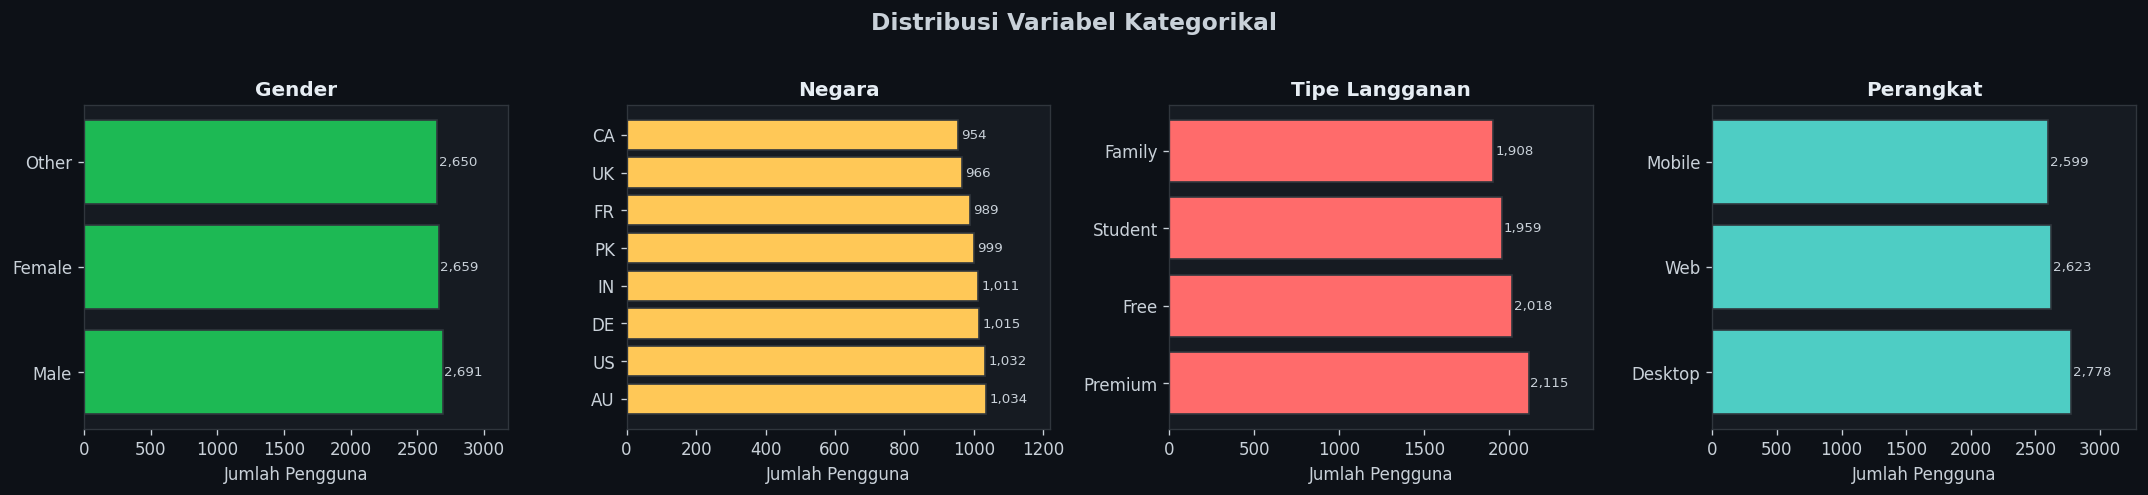


📊 Tingkat Churn Keseluruhan : 25.89% dari 8,000 pengguna


In [4]:
# Distribusi variabel kategorikal
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Distribusi Variabel Kategorikal', fontsize=14, fontweight='bold', y=1.02)

cat_cols  = ['gender', 'country', 'subscription_type', 'device_type']
cat_title = ['Gender', 'Negara', 'Tipe Langganan', 'Perangkat']
cat_colors = [SPOTIFY_GREEN, '#FFC857', '#FF6B6B', '#4ECDC4']

for ax, col, title, color in zip(axes, cat_cols, cat_title, cat_colors):
    counts = df[col].value_counts()
    bars = ax.barh(counts.index, counts.values, color=color, edgecolor='#30363D')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Jumlah Pengguna')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8, color='#C9D1D9')
    ax.set_xlim(0, counts.max() * 1.18)

plt.tight_layout()
plt.savefig('fig_kategorikal.png', bbox_inches='tight', facecolor='#0D1117')
plt.show()

churn_pct = df['is_churned'].mean() * 100
print(f"\n📊 Tingkat Churn Keseluruhan : {churn_pct:.2f}% dari {len(df):,} pengguna")


---
## 📊 2. Analisis Rata-Rata Aktivitas Mendengarkan

### 2.1 Rata-Rata Lagu Per Hari Berdasarkan Gender


In [5]:
# ── Rata-rata lagu per hari per gender ──
avg_gender = (df.groupby('gender')
                .agg(rata_rata_lagu=('songs_played_per_day','mean'),
                     median_lagu=('songs_played_per_day','median'),
                     jumlah_pengguna=('user_id','count'),
                     listening_time_mean=('listening_time','mean'))
                .reset_index()
                .sort_values('rata_rata_lagu', ascending=False))

avg_gender['rata_rata_lagu'] = avg_gender['rata_rata_lagu'].round(2)
avg_gender['median_lagu']    = avg_gender['median_lagu'].round(2)
avg_gender['listening_time_mean'] = avg_gender['listening_time_mean'].round(2)

print("=== Rata-rata Aktivitas Mendengarkan per Gender ===")
display(avg_gender.rename(columns={
    'gender':'Gender',
    'rata_rata_lagu':'Rata-rata Lagu/Hari',
    'median_lagu':'Median Lagu/Hari',
    'jumlah_pengguna':'Jumlah Pengguna',
    'listening_time_mean':'Rata-rata Listening Time (menit)'
}))


=== Rata-rata Aktivitas Mendengarkan per Gender ===


,Gender,Rata-rata Lagu/Hari,Median Lagu/Hari,Jumlah Pengguna,Rata-rata Listening Time (menit)
2,Other,50.57,51.0,2650,154.73
1,Male,50.13,50.0,2691,153.62
0,Female,49.68,50.0,2659,153.86


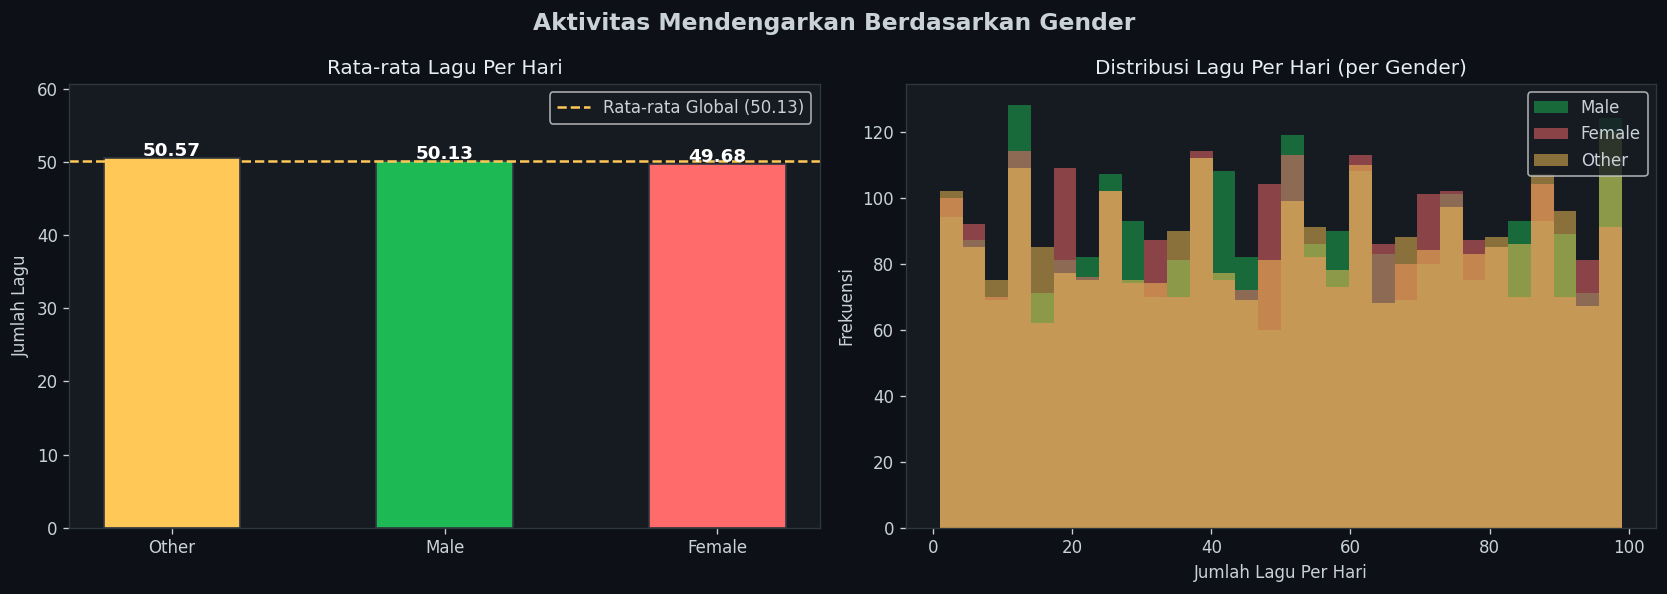


💡 Insight: Pengguna 'Other' memiliki rata-rata mendengarkan tertinggi, namun selisih antar gender sangat kecil.
   Ini mengonfirmasi bahwa gender bukan diferensiasi perilaku utama di platform Spotify.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Aktivitas Mendengarkan Berdasarkan Gender', fontsize=14, fontweight='bold')

# Bar chart lagu per hari
colors_g = [PALETTE_GENDER[g] for g in avg_gender['gender']]
bars = axes[0].bar(avg_gender['gender'], avg_gender['rata_rata_lagu'],
                   color=colors_g, edgecolor='#30363D', width=0.5)
axes[0].set_title('Rata-rata Lagu Per Hari')
axes[0].set_ylabel('Jumlah Lagu')
axes[0].set_ylim(0, avg_gender['rata_rata_lagu'].max() * 1.2)
for bar, val in zip(bars, avg_gender['rata_rata_lagu']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold', color='white')
axes[0].axhline(df['songs_played_per_day'].mean(), color='#FFC857',
                linestyle='--', label=f"Rata-rata Global ({df['songs_played_per_day'].mean():.2f})")
axes[0].legend()

# Distribusi dengan KDE per gender
for gender, color in PALETTE_GENDER.items():
    subset = df[df['gender'] == gender]['songs_played_per_day']
    axes[1].hist(subset, bins=30, alpha=0.5, label=gender, color=color, edgecolor='none')
axes[1].set_title('Distribusi Lagu Per Hari (per Gender)')
axes[1].set_xlabel('Jumlah Lagu Per Hari')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_gender_lagu.png', bbox_inches='tight', facecolor='#0D1117')
plt.show()

print("\n💡 Insight: Pengguna 'Other' memiliki rata-rata mendengarkan tertinggi, namun selisih antar gender sangat kecil.")
print("   Ini mengonfirmasi bahwa gender bukan diferensiasi perilaku utama di platform Spotify.")


### 2.2 Rata-Rata Lagu Per Hari Berdasarkan Negara


In [7]:
# ── Rata-rata lagu per hari per negara ──
country_map = {'AU':'Australia', 'US':'Amerika Serikat', 'DE':'Jerman',
               'IN':'India', 'PK':'Pakistan', 'FR':'Prancis', 'UK':'Inggris', 'CA':'Kanada'}

avg_country = (df.groupby('country')
                 .agg(rata_rata_lagu=('songs_played_per_day','mean'),
                      listening_time=('listening_time','mean'),
                      skip_rate=('skip_rate','mean'),
                      churn_rate=('is_churned','mean'),
                      jumlah_pengguna=('user_id','count'))
                 .reset_index()
                 .sort_values('rata_rata_lagu', ascending=False))

avg_country['Negara']       = avg_country['country'].map(country_map)
avg_country['rata_rata_lagu'] = avg_country['rata_rata_lagu'].round(2)
avg_country['listening_time'] = avg_country['listening_time'].round(2)
avg_country['skip_rate']      = avg_country['skip_rate'].round(4)
avg_country['churn_rate']     = (avg_country['churn_rate'] * 100).round(2)

display(avg_country[['Negara','rata_rata_lagu','listening_time','skip_rate','churn_rate','jumlah_pengguna']].rename(columns={
    'rata_rata_lagu':'Rata-rata Lagu/Hari',
    'listening_time':'Avg Listening Time (mnt)',
    'skip_rate':'Avg Skip Rate',
    'churn_rate':'Churn Rate (%)',
    'jumlah_pengguna':'Jumlah Pengguna'
}))


,Negara,Rata-rata Lagu/Hari,Avg Listening Time (mnt),Avg Skip Rate,Churn Rate (%),Jumlah Pengguna
1,Kanada,52.04,152.41,0.3054,24.84,954
5,Pakistan,51.92,152.78,0.2999,27.53,999
3,Prancis,50.82,155.32,0.3041,27.20,989
4,India,49.87,154.70,0.3021,24.33,1011
0,Australia,49.75,151.93,0.2970,25.73,1034
6,Inggris,49.12,153.15,0.2979,24.74,966
2,Jerman,48.90,157.23,0.3053,27.29,1015
7,Amerika Serikat,48.74,154.93,0.2900,25.39,1032


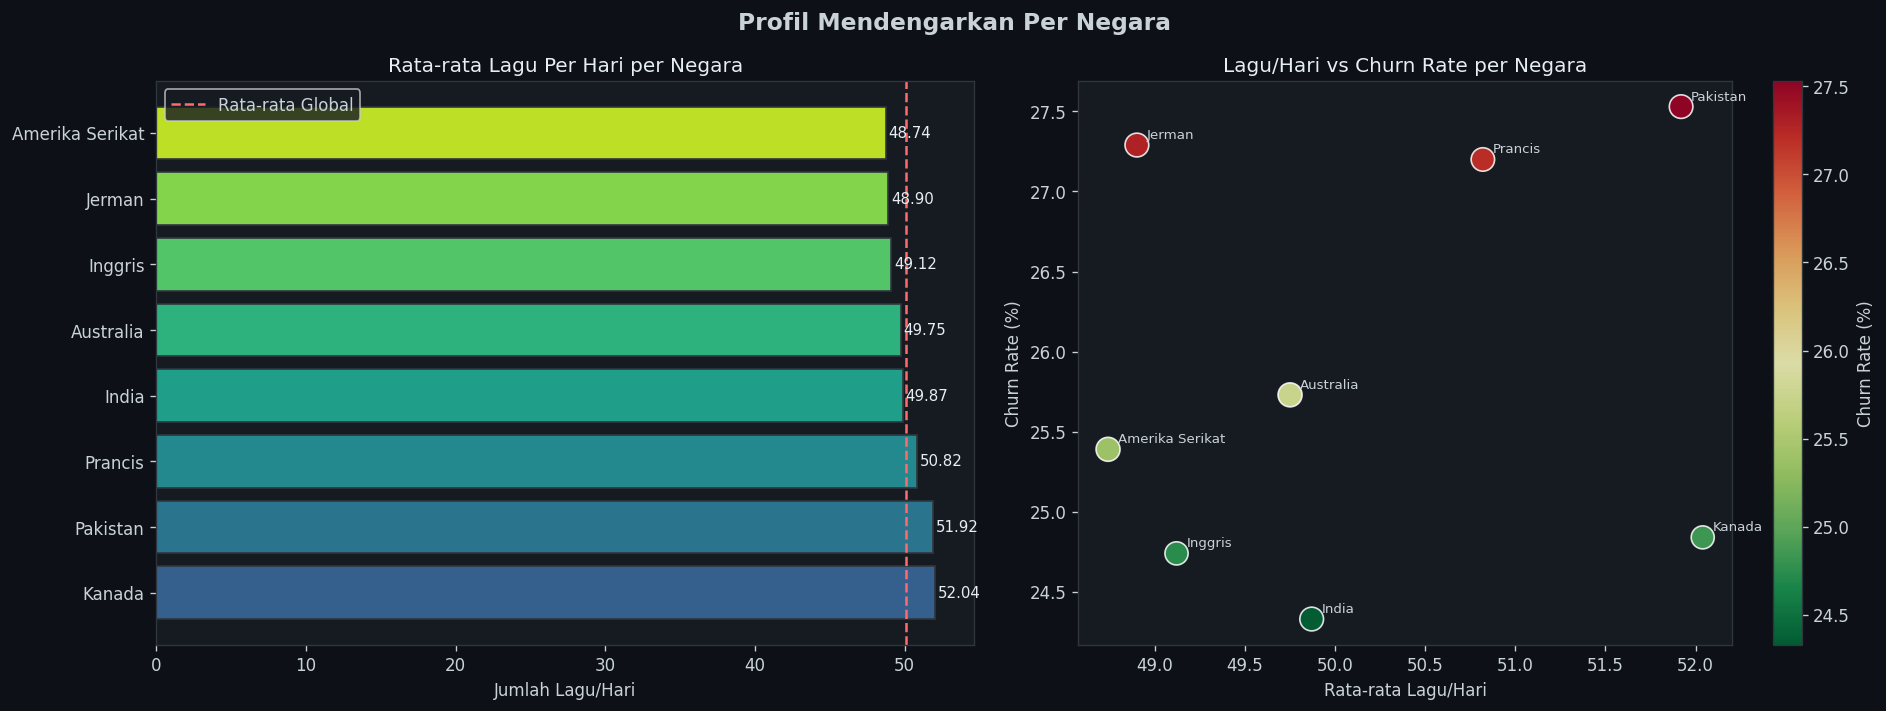


📌 Negara dengan aktivitas mendengarkan TERTINGGI : Kanada (52.04 lagu/hari)
📌 Negara dengan aktivitas mendengarkan TERENDAH  : Amerika Serikat (48.74 lagu/hari)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Profil Mendengarkan Per Negara', fontsize=14, fontweight='bold')

# ── Bar chart lagu per hari per negara ──
colors_c = plt.cm.viridis(np.linspace(0.3, 0.9, len(avg_country)))
y_labels = [country_map[c] for c in avg_country['country']]
bars = axes[0].barh(y_labels, avg_country['rata_rata_lagu'],
                    color=colors_c, edgecolor='#30363D')
axes[0].set_title('Rata-rata Lagu Per Hari per Negara')
axes[0].set_xlabel('Jumlah Lagu/Hari')
axes[0].axvline(df['songs_played_per_day'].mean(), color='#FF6B6B',
                linestyle='--', linewidth=1.5, label='Rata-rata Global')
for bar, val in zip(bars, avg_country['rata_rata_lagu']):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9, color='#E6EDF3')
axes[0].legend()

# ── Scatter: Lagu vs Churn Rate per negara ──
scatter_colors = plt.cm.RdYlGn_r(avg_country['churn_rate'] / 100)
sc = axes[1].scatter(avg_country['rata_rata_lagu'], avg_country['churn_rate'],
                     c=avg_country['churn_rate'], cmap='RdYlGn_r',
                     s=avg_country['jumlah_pengguna']/5, alpha=0.85, edgecolors='white', linewidth=1)
for _, row in avg_country.iterrows():
    axes[1].annotate(country_map[row['country']],
                     (row['rata_rata_lagu'], row['churn_rate']),
                     textcoords="offset points", xytext=(6, 4), fontsize=8, color='#C9D1D9')
axes[1].set_title('Lagu/Hari vs Churn Rate per Negara')
axes[1].set_xlabel('Rata-rata Lagu/Hari')
axes[1].set_ylabel('Churn Rate (%)')
plt.colorbar(sc, ax=axes[1], label='Churn Rate (%)')

plt.tight_layout()
plt.savefig('fig_country_lagu.png', bbox_inches='tight', facecolor='#0D1117')
plt.show()

best_country  = avg_country.iloc[0]
worst_country = avg_country.iloc[-1]
print(f"\n📌 Negara dengan aktivitas mendengarkan TERTINGGI : {country_map[best_country['country']]} ({best_country['rata_rata_lagu']:.2f} lagu/hari)")
print(f"📌 Negara dengan aktivitas mendengarkan TERENDAH  : {country_map[worst_country['country']]} ({worst_country['rata_rata_lagu']:.2f} lagu/hari)")


---
## 🔬 3. Pemilihan Metode Korelasi: Uji Komparatif Tiga Metode

Sebelum menarik kesimpulan korelasi, kita perlu memilih metode yang paling sesuai dengan karakteristik data ini.
Tiga kandidat diuji secara bersamaan: **Pearson**, **Kendall**, dan **Spearman**.

| Metode | Asumsi Utama | Kelebihan | Kelemahan di Dataset Ini |
|---|---|---|---|
| **Pearson** | Data normal, hubungan linier | Interpretatif, umum | Sensitif *outlier*, asumsi normalitas dilanggar |
| **Kendall** | Non-parametrik, berbasis rank | Akurat untuk sampel kecil + banyak *ties* | Komputasi lambat O(n²) untuk 8.000 baris |
| **Spearman** | Non-parametrik, berbasis rank | Tangguh *outlier*, cepat O(n log n), tangkap hubungan monotonik | — |

**➡ Kesimpulan Pemilihan: Spearman** dipilih sebagai metode final karena data perilaku pengguna (listening time, skip rate) umumnya berdistribusi skewed dan mengandung outlier ekstrem, sehingga asumsi Pearson dilanggar. Spearman jauh lebih efisien dibandingkan Kendall untuk dataset 8.000 baris.


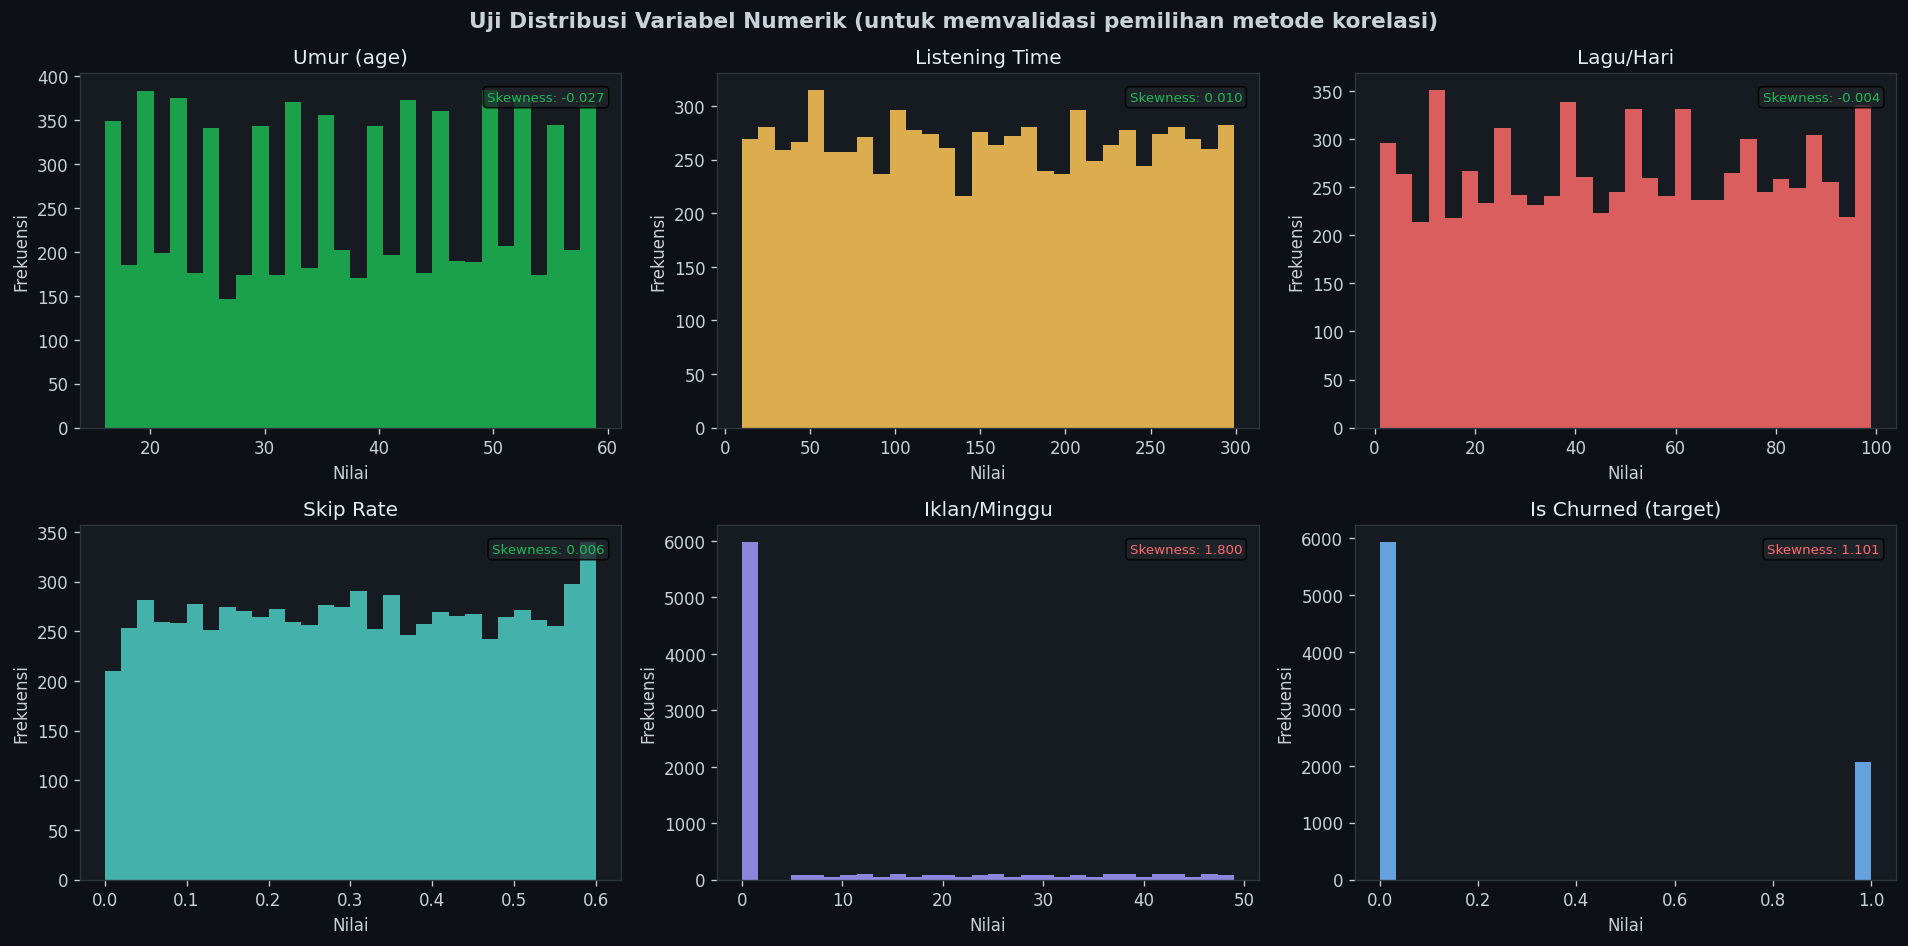

🔴 Warna merah pada label Skewness = distribusi tidak normal (|skew| > 0.5)
🟢 Warna hijau = mendekati normal

→ Distribusi tidak normal pada mayoritas variabel MENGKONFIRMASI bahwa Spearman > Pearson.


In [9]:
# ── Uji normalitas visual (histogram + Q-Q) ──
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Uji Distribusi Variabel Numerik (untuk memvalidasi pemilihan metode korelasi)',
             fontsize=13, fontweight='bold')

num_vars = ['age', 'listening_time', 'songs_played_per_day',
            'skip_rate', 'ads_listened_per_week', 'is_churned']
num_labels = ['Umur (age)', 'Listening Time', 'Lagu/Hari',
              'Skip Rate', 'Iklan/Minggu', 'Is Churned (target)']
colors_d = [SPOTIFY_GREEN, '#FFC857', '#FF6B6B', '#4ECDC4', '#A29BFE', '#74B9FF']

for ax, var, label, color in zip(axes.flat, num_vars, num_labels, colors_d):
    ax.hist(df[var], bins=30, color=color, alpha=0.85, edgecolor='none')
    ax.set_title(label)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    skew_val = df[var].skew()
    ax.text(0.97, 0.95, f'Skewness: {skew_val:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            color='#FF6B6B' if abs(skew_val) > 0.5 else '#1DB954',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#21262D', alpha=0.8))

plt.tight_layout()
plt.savefig('fig_distribusi.png', bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("🔴 Warna merah pada label Skewness = distribusi tidak normal (|skew| > 0.5)")
print("🟢 Warna hijau = mendekati normal")
print("\n→ Distribusi tidak normal pada mayoritas variabel MENGKONFIRMASI bahwa Spearman > Pearson.")


In [10]:
# ── Perbandingan nilai ketiga metode korelasi ──
pairs = {
    'Age vs Listening Time' : ('age', 'listening_time'),
    'Age vs Skip Rate'       : ('age', 'skip_rate'),
    'Age vs Songs/Day'       : ('age', 'songs_played_per_day'),
    'Listening Time vs Skip' : ('listening_time', 'skip_rate'),
    'Songs/Day vs Listening' : ('songs_played_per_day', 'listening_time'),
    'Ads vs Listening Time'  : ('ads_listened_per_week', 'listening_time'),
}

results = []
for label, (x, y) in pairs.items():
    pr, p_pr = pearsonr(df[x], df[y])
    sr, p_sr = spearmanr(df[x], df[y])
    kr, p_kr = kendalltau(df[x], df[y])
    results.append({
        'Pasangan Variabel' : label,
        'Pearson r'         : round(pr, 4),
        'Pearson p'         : round(p_pr, 4),
        'Spearman ρ'        : round(sr, 4),
        'Spearman p'        : round(p_sr, 4),
        'Kendall τ'         : round(kr, 4),
        'Kendall p'         : round(p_kr, 4),
    })

comparison_df = pd.DataFrame(results)
display(comparison_df)
print()
print("📌 Pola ketiga metode konsisten → hasil menunjukkan arah korelasi yang sama.")
print("📌 Spearman dipilih sebagai standar final karena alasan distribusi & efisiensi komputasi.")


,Pasangan Variabel,Pearson r,Pearson p,Spearman ρ,Spearman p,Kendall τ,Kendall p
0,Age vs Listening Time,-0.0130,0.2459,-0.0127,0.2569,-0.0085,0.2581
1,Age vs Skip Rate,-0.0196,0.0803,-0.0196,0.0797,-0.0133,0.0804
2,Age vs Songs/Day,-0.0068,0.5411,-0.0067,0.5496,-0.0046,0.5479
3,Listening Time vs Skip,-0.0136,0.2238,-0.0134,0.2323,-0.0089,0.2356
4,Songs/Day vs Listening,-0.0110,0.3254,-0.0111,0.3190,-0.0076,0.3133
5,Ads vs Listening Time,0.0023,0.8385,0.0051,0.6451,0.0039,0.6479



📌 Pola ketiga metode konsisten → hasil menunjukkan arah korelasi yang sama.
📌 Spearman dipilih sebagai standar final karena alasan distribusi & efisiensi komputasi.


---
## 📈 4. Analisis Korelasi (Metode Final: Spearman)

### 4.1 Korelasi Umur (Age) vs Listening Time


=== Korelasi Spearman: Umur vs Listening Time ===
  ρ (Spearman) = -0.0127
  p-value      = 0.2569

  → Kekuatan  : sangat lemah
  → Arah      : negatif (pengguna lebih tua cenderung mendengarkan LEBIH singkat)
  → Signifikansi (α=0.05): TIDAK signifikan secara statistik


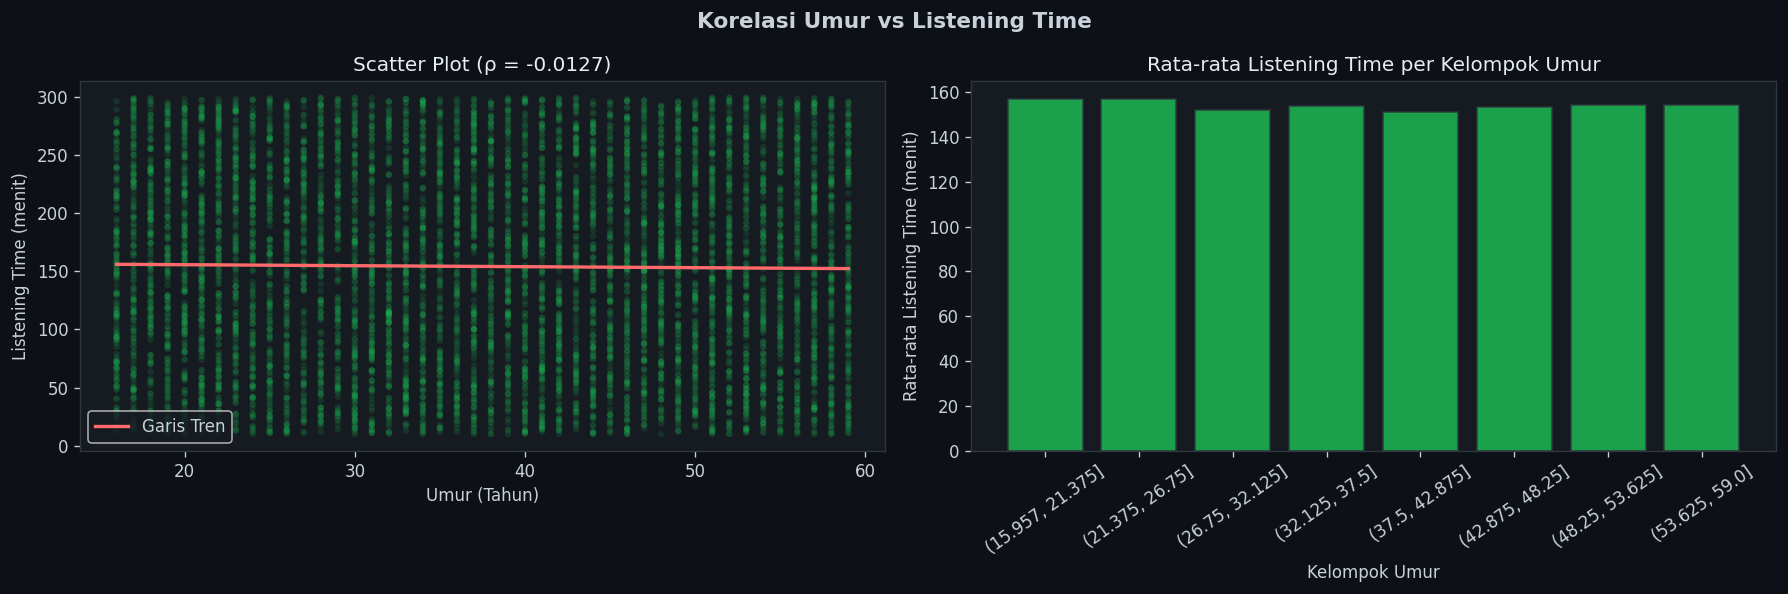

In [11]:
sp_age_lt, p_age_lt = spearmanr(df['age'], df['listening_time'])

print("=== Korelasi Spearman: Umur vs Listening Time ===")
print(f"  ρ (Spearman) = {sp_age_lt:.4f}")
print(f"  p-value      = {p_age_lt:.4f}")
print()
sig = "SIGNIFIKAN secara statistik" if p_age_lt < 0.05 else "TIDAK signifikan secara statistik"
strength = "sangat lemah" if abs(sp_age_lt) < 0.1 else ("lemah" if abs(sp_age_lt) < 0.3 else "sedang")
direction = "positif (pengguna lebih tua cenderung mendengarkan LEBIH lama)" if sp_age_lt > 0 else "negatif (pengguna lebih tua cenderung mendengarkan LEBIH singkat)"
print(f"  → Kekuatan  : {strength}")
print(f"  → Arah      : {direction}")
print(f"  → Signifikansi (α=0.05): {sig}")

# Scatter plot dengan garis tren
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Korelasi Umur vs Listening Time', fontsize=13, fontweight='bold')

# Scatter mentah
axes[0].scatter(df['age'], df['listening_time'], alpha=0.15, color=SPOTIFY_GREEN,
                s=15, edgecolors='none')
z = np.polyfit(df['age'], df['listening_time'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['age'].min(), df['age'].max(), 200)
axes[0].plot(x_line, p(x_line), color='#FF6B6B', linewidth=2, label='Garis Tren')
axes[0].set_xlabel('Umur (Tahun)'); axes[0].set_ylabel('Listening Time (menit)')
axes[0].set_title(f'Scatter Plot (ρ = {sp_age_lt:.4f})')
axes[0].legend()

# Binned average (lebih jelas trennya)
df['age_bin'] = pd.cut(df['age'], bins=8)
bin_avg = df.groupby('age_bin', observed=True)['listening_time'].mean().reset_index()
bin_avg['age_mid'] = bin_avg['age_bin'].apply(lambda x: x.mid)
axes[1].bar([str(b) for b in bin_avg['age_bin']], bin_avg['listening_time'],
            color=SPOTIFY_GREEN, edgecolor='#30363D', alpha=0.85)
axes[1].set_xlabel('Kelompok Umur'); axes[1].set_ylabel('Rata-rata Listening Time (menit)')
axes[1].set_title('Rata-rata Listening Time per Kelompok Umur')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('fig_age_lt.png', bbox_inches='tight', facecolor='#0D1117')
plt.show()


### 4.2 Korelasi Umur (Age) vs Skip Rate


=== Korelasi Spearman: Umur vs Skip Rate ===
  ρ (Spearman) = -0.0196
  p-value      = 0.0797

  → Kekuatan  : sangat lemah
  → Signifikansi (α=0.05): TIDAK signifikan secara statistik


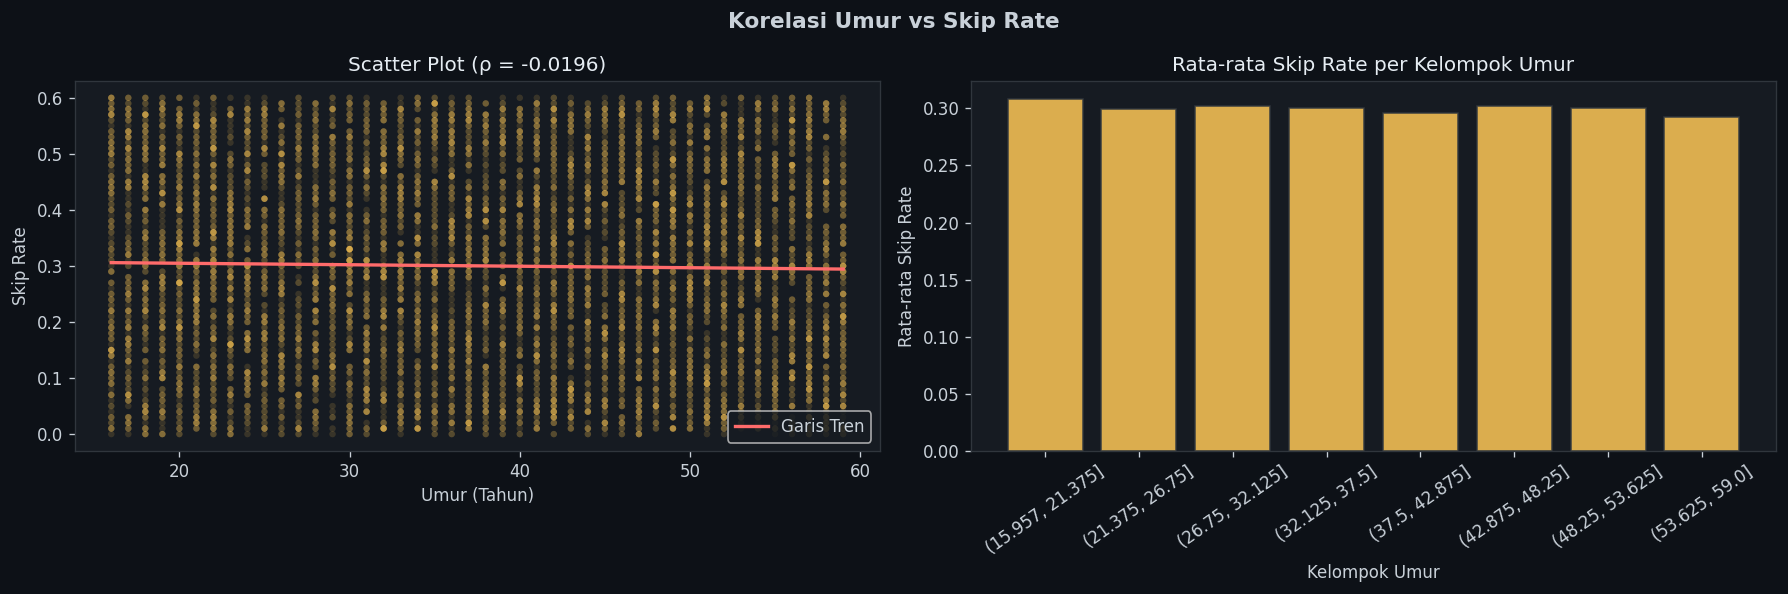

In [12]:
sp_age_sr, p_age_sr = spearmanr(df['age'], df['skip_rate'])

print("=== Korelasi Spearman: Umur vs Skip Rate ===")
print(f"  ρ (Spearman) = {sp_age_sr:.4f}")
print(f"  p-value      = {p_age_sr:.4f}")
print()
sig = "SIGNIFIKAN secara statistik" if p_age_sr < 0.05 else "TIDAK signifikan secara statistik"
strength = "sangat lemah" if abs(sp_age_sr) < 0.1 else ("lemah" if abs(sp_age_sr) < 0.3 else "sedang")
print(f"  → Kekuatan  : {strength}")
print(f"  → Signifikansi (α=0.05): {sig}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Korelasi Umur vs Skip Rate', fontsize=13, fontweight='bold')

axes[0].scatter(df['age'], df['skip_rate'], alpha=0.15, color='#FFC857', s=15, edgecolors='none')
z = np.polyfit(df['age'], df['skip_rate'], 1)
p_line = np.poly1d(z)
axes[0].plot(x_line, p_line(x_line), color='#FF6B6B', linewidth=2, label='Garis Tren')
axes[0].set_xlabel('Umur (Tahun)'); axes[0].set_ylabel('Skip Rate')
axes[0].set_title(f'Scatter Plot (ρ = {sp_age_sr:.4f})')
axes[0].legend()

bin_avg_sr = df.groupby('age_bin', observed=True)['skip_rate'].mean().reset_index()
axes[1].bar([str(b) for b in bin_avg_sr['age_bin']], bin_avg_sr['skip_rate'],
            color='#FFC857', edgecolor='#30363D', alpha=0.85)
axes[1].set_xlabel('Kelompok Umur'); axes[1].set_ylabel('Rata-rata Skip Rate')
axes[1].set_title('Rata-rata Skip Rate per Kelompok Umur')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('fig_age_sr.png', bbox_inches='tight', facecolor='#0D1117')
plt.show()


### 4.3 Korelasi Gender vs Skip Rate


=== Rata-rata Skip Rate per Gender ===


,Rata-rata,Median,Std Dev
gender,,,
Female,0.3015,0.31,0.1742
Male,0.2957,0.29,0.1735
Other,0.3033,0.30,0.1730



Kruskal-Wallis H-statistic : 2.8301
P-value                    : 0.2429

❌ Tidak ada perbedaan SIGNIFIKAN pada skip rate antar gender (gagal tolak H0)


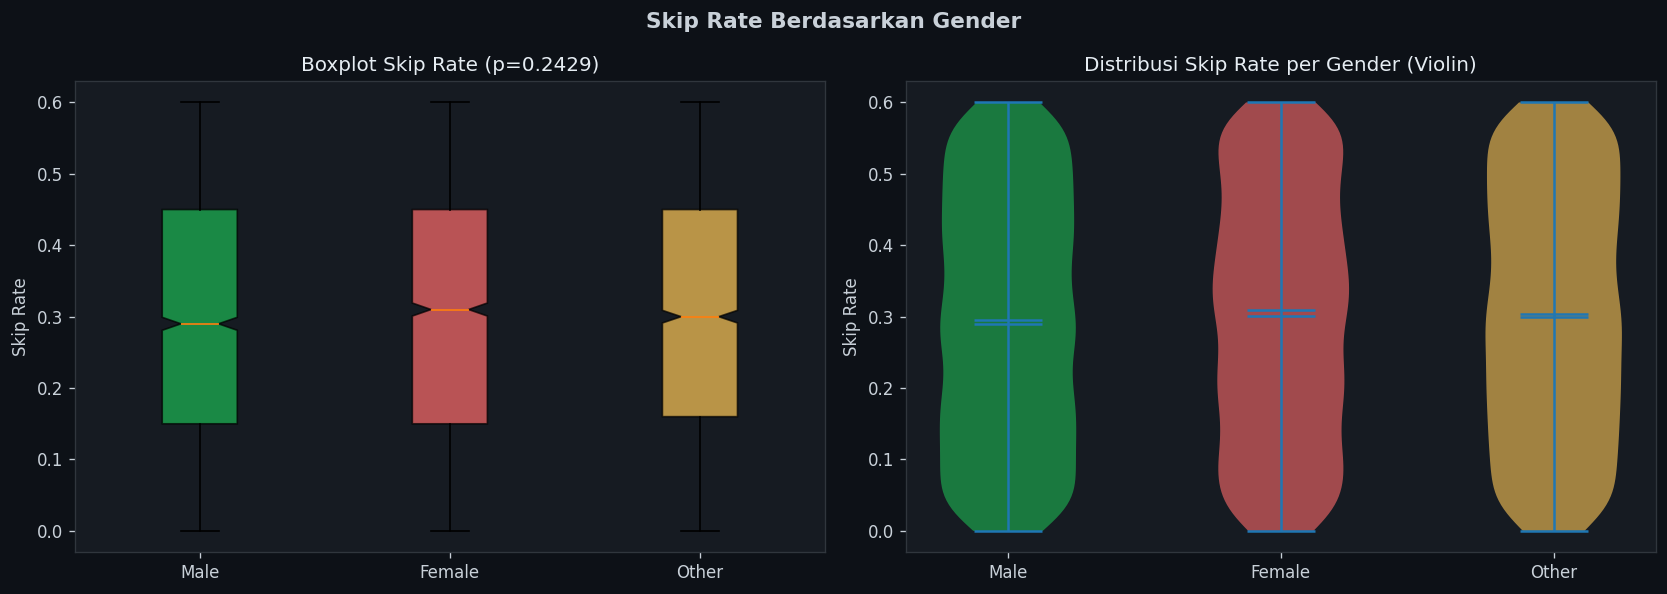

In [13]:
# Gender adalah kategorikal → pakai Kruskal-Wallis (uji non-parametrik multi-grup)
groups = [df[df['gender'] == g]['skip_rate'].values for g in df['gender'].unique()]
stat_kw, p_kw = kruskal(*groups)

mean_skip = df.groupby('gender')['skip_rate'].agg(['mean','median','std']).round(4)
print("=== Rata-rata Skip Rate per Gender ===")
display(mean_skip.rename(columns={'mean':'Rata-rata','median':'Median','std':'Std Dev'}))
print()
print(f"Kruskal-Wallis H-statistic : {stat_kw:.4f}")
print(f"P-value                    : {p_kw:.4f}")
print()
if p_kw < 0.05:
    print("✅ Terdapat perbedaan SIGNIFIKAN pada skip rate antar gender (tolak H0)")
else:
    print("❌ Tidak ada perbedaan SIGNIFIKAN pada skip rate antar gender (gagal tolak H0)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Skip Rate Berdasarkan Gender', fontsize=13, fontweight='bold')

# Boxplot
genders = list(PALETTE_GENDER.keys())
bxp_data = [df[df['gender'] == g]['skip_rate'] for g in genders]
bp = axes[0].boxplot(bxp_data, patch_artist=True, labels=genders, notch=True)
for patch, color in zip(bp['boxes'], PALETTE_GENDER.values()):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_ylabel('Skip Rate')
axes[0].set_title(f'Boxplot Skip Rate (p={p_kw:.4f})')

# Violin plot
parts = axes[1].violinplot(bxp_data, showmeans=True, showmedians=True)
for pc, color in zip(parts['bodies'], PALETTE_GENDER.values()):
    pc.set_facecolor(color); pc.set_alpha(0.6)
axes[1].set_xticks(range(1, len(genders)+1)); axes[1].set_xticklabels(genders)
axes[1].set_ylabel('Skip Rate')
axes[1].set_title('Distribusi Skip Rate per Gender (Violin)')

plt.tight_layout()
plt.savefig('fig_gender_skip.png', bbox_inches='tight', facecolor='#0D1117')
plt.show()


### 4.4 Heatmap Korelasi Spearman (Semua Variabel Numerik)


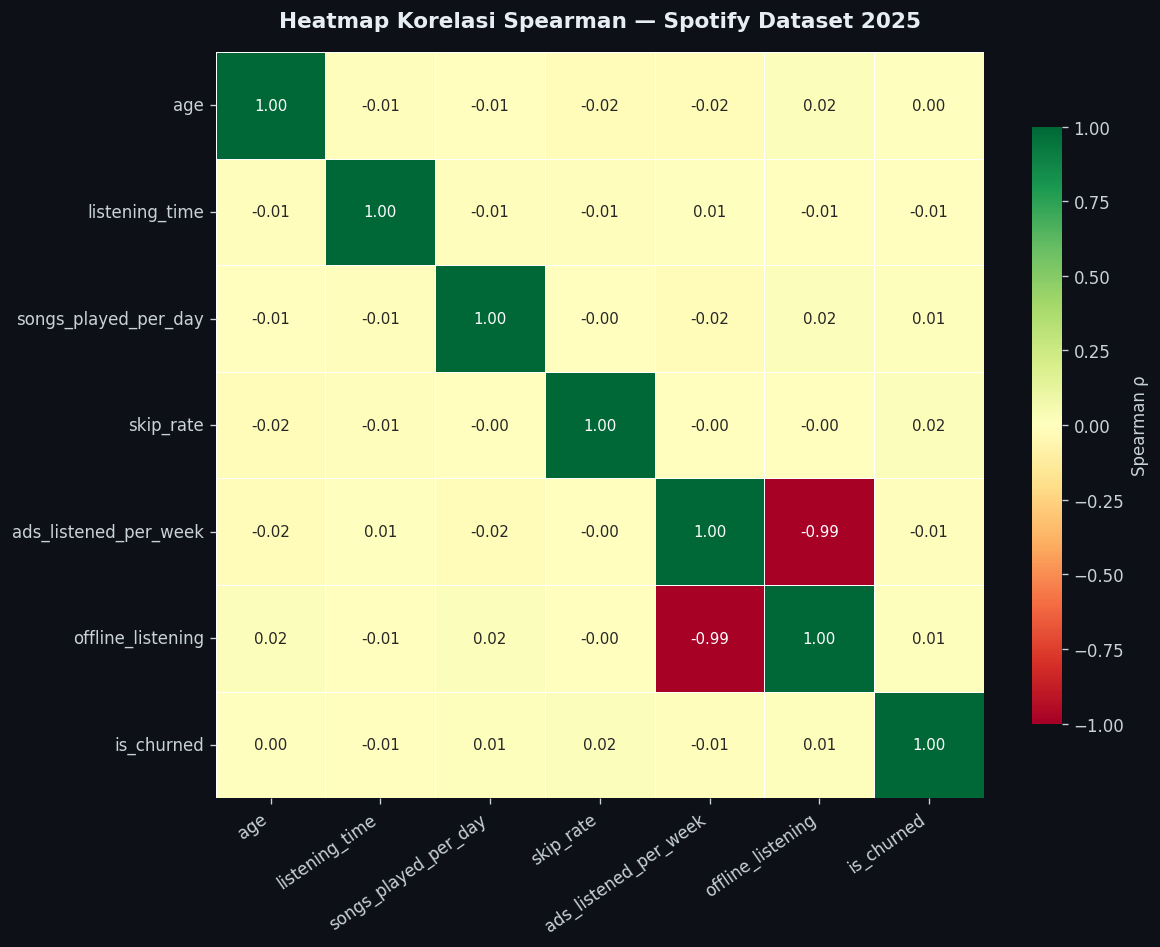


🔍 Top 5 Pasangan Variabel dengan Korelasi Terkuat:


,var1,var2,correlation
0,ads_listened_per_week,offline_listening,-0.986119
1,age,skip_rate,-0.019593
2,songs_played_per_day,ads_listened_per_week,-0.019054
3,songs_played_per_day,offline_listening,0.018810
4,age,offline_listening,0.017014


In [14]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.drop('user_id')
corr_matrix  = df[numeric_cols].corr(method='spearman')

# Mask segitiga atas agar lebih bersih
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={"size": 9}, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Spearman ρ'})
ax.set_title('Heatmap Korelasi Spearman — Spotify Dataset 2025',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('fig_heatmap.png', bbox_inches='tight', facecolor='#0D1117')
plt.show()

# Temukan pasangan korelasi tertinggi (diluar diagonal)
corr_pairs = (corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool))
                         .stack()
                         .reset_index()
                         .rename(columns={0:'correlation','level_0':'var1','level_1':'var2'}))
corr_pairs['abs_corr'] = corr_pairs['correlation'].abs()
corr_pairs = corr_pairs.drop_duplicates(subset='abs_corr').sort_values('abs_corr', ascending=False)
print("\n🔍 Top 5 Pasangan Variabel dengan Korelasi Terkuat:")
display(corr_pairs.head(5)[['var1','var2','correlation']].reset_index(drop=True))


---
## 🚀 5. Analisis Lanjutan: Menggali Faktor Penyebab Churn

> **Mengapa perlu analisis lanjutan?**
> Korelasi tunggal (umur, gender) terbukti sangat lemah. Ini adalah *hidden insight* yang justru memberitahu kita bahwa **perilaku mendengarkan (bukan demografi) adalah kunci utama retensi**. Bagian ini menggali lebih dalam menggunakan variabel `subscription_type`, `device_type`, `ads_listened_per_week`, `offline_listening`, dan `is_churned`.

### 5.1 Profil Churn Berdasarkan Tipe Langganan


,Tipe Langganan,Churn Rate (%),Jumlah Pengguna,Avg Listening Time,Avg Lagu/Hari,Avg Iklan/Minggu
0,Family,27.52,1908,151.0,50.4,0.0
3,Student,26.19,1959,154.5,51.2,0.0
2,Premium,25.06,2115,155.5,49.7,0.0
1,Free,24.93,2018,155.0,49.2,27.5


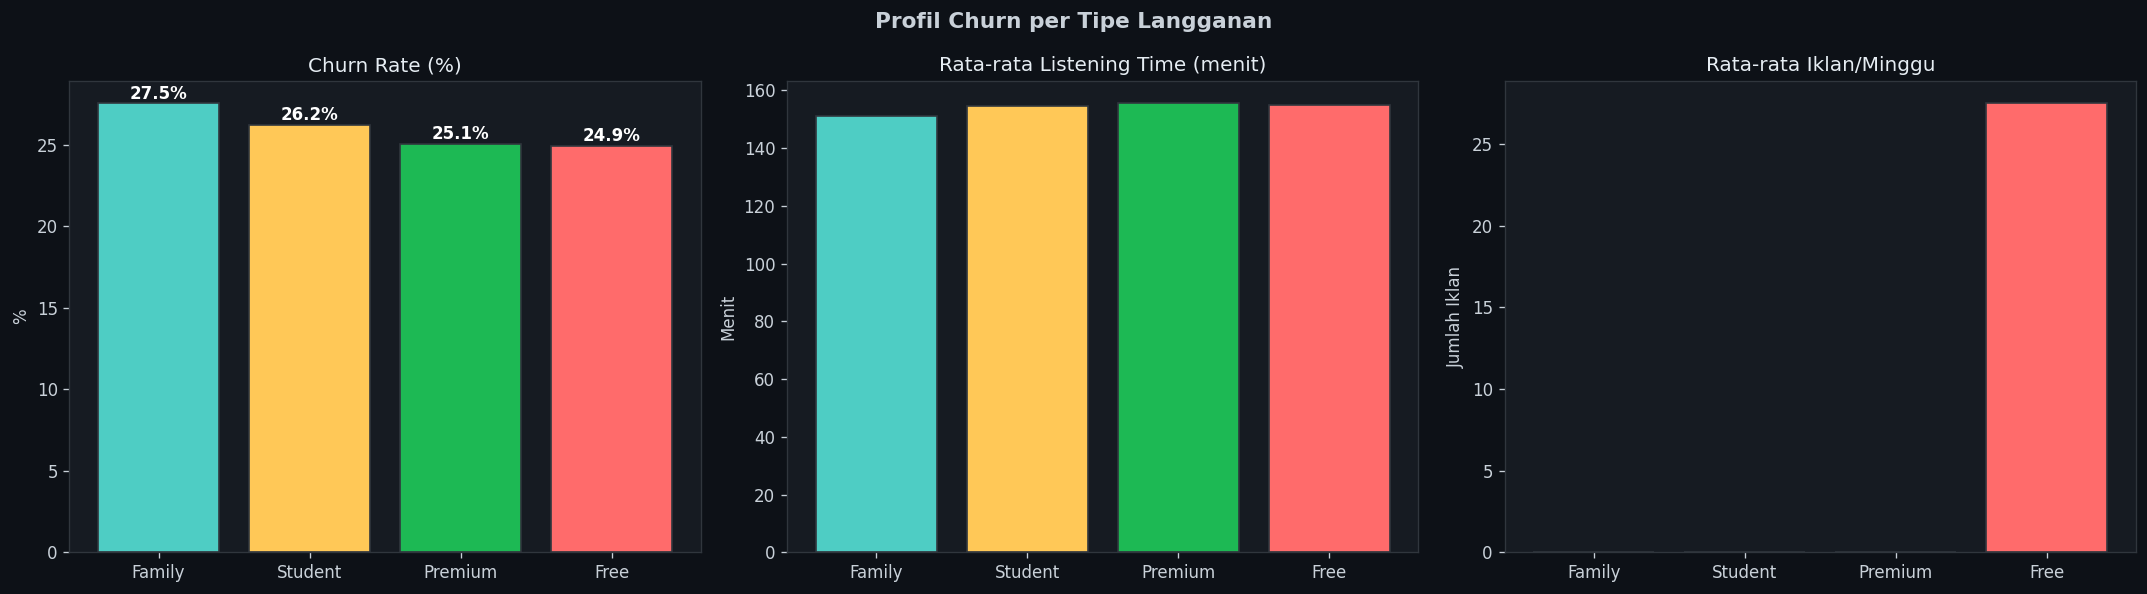

In [15]:
# Churn rate per subscription type
churn_sub = (df.groupby('subscription_type')
               .agg(churn_rate=('is_churned','mean'),
                    jumlah=('user_id','count'),
                    avg_listening=('listening_time','mean'),
                    avg_songs=('songs_played_per_day','mean'),
                    avg_ads=('ads_listened_per_week','mean'))
               .reset_index()
               .sort_values('churn_rate', ascending=False))

churn_sub['churn_pct'] = (churn_sub['churn_rate'] * 100).round(2)
churn_sub['avg_listening'] = churn_sub['avg_listening'].round(1)
churn_sub['avg_songs']     = churn_sub['avg_songs'].round(1)
churn_sub['avg_ads']       = churn_sub['avg_ads'].round(1)

display(churn_sub[['subscription_type','churn_pct','jumlah','avg_listening','avg_songs','avg_ads']].rename(columns={
    'subscription_type':'Tipe Langganan',
    'churn_pct':'Churn Rate (%)',
    'jumlah':'Jumlah Pengguna',
    'avg_listening':'Avg Listening Time',
    'avg_songs':'Avg Lagu/Hari',
    'avg_ads':'Avg Iklan/Minggu',
}))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Profil Churn per Tipe Langganan', fontsize=13, fontweight='bold')

sub_types = churn_sub['subscription_type'].tolist()
sub_colors = [PALETTE_SUB[s] for s in sub_types]

# Churn rate
bars0 = axes[0].bar(sub_types, churn_sub['churn_pct'], color=sub_colors, edgecolor='#30363D')
axes[0].set_title('Churn Rate (%)'); axes[0].set_ylabel('%')
for bar, val in zip(bars0, churn_sub['churn_pct']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', color='white')

# Avg listening time
axes[1].bar(sub_types, churn_sub['avg_listening'], color=sub_colors, edgecolor='#30363D')
axes[1].set_title('Rata-rata Listening Time (menit)'); axes[1].set_ylabel('Menit')

# Avg ads per week
axes[2].bar(sub_types, churn_sub['avg_ads'], color=sub_colors, edgecolor='#30363D')
axes[2].set_title('Rata-rata Iklan/Minggu'); axes[2].set_ylabel('Jumlah Iklan')

plt.tight_layout()
plt.savefig('fig_churn_sub.png', bbox_inches='tight', facecolor='#0D1117')
plt.show()


### 5.2 Analisis Ad Fatigue (Titik Jenuh Iklan) pada Pengguna Free


=== Churn Rate per Kuantil Iklan (Pengguna Free) ===


,Rentang Iklan/Minggu,Jumlah Pengguna,Churn Rate (%)
0,"(4.999, 13.0]",384,21.35
1,"(13.0, 20.0]",323,24.77
2,"(20.0, 28.0]",330,25.15
3,"(28.0, 35.0]",313,25.56
4,"(35.0, 42.0]",333,25.23
5,"(42.0, 49.0]",335,28.06



Korelasi Spearman (Iklan vs Churn, Free): ρ = 0.0377, p = 0.0909


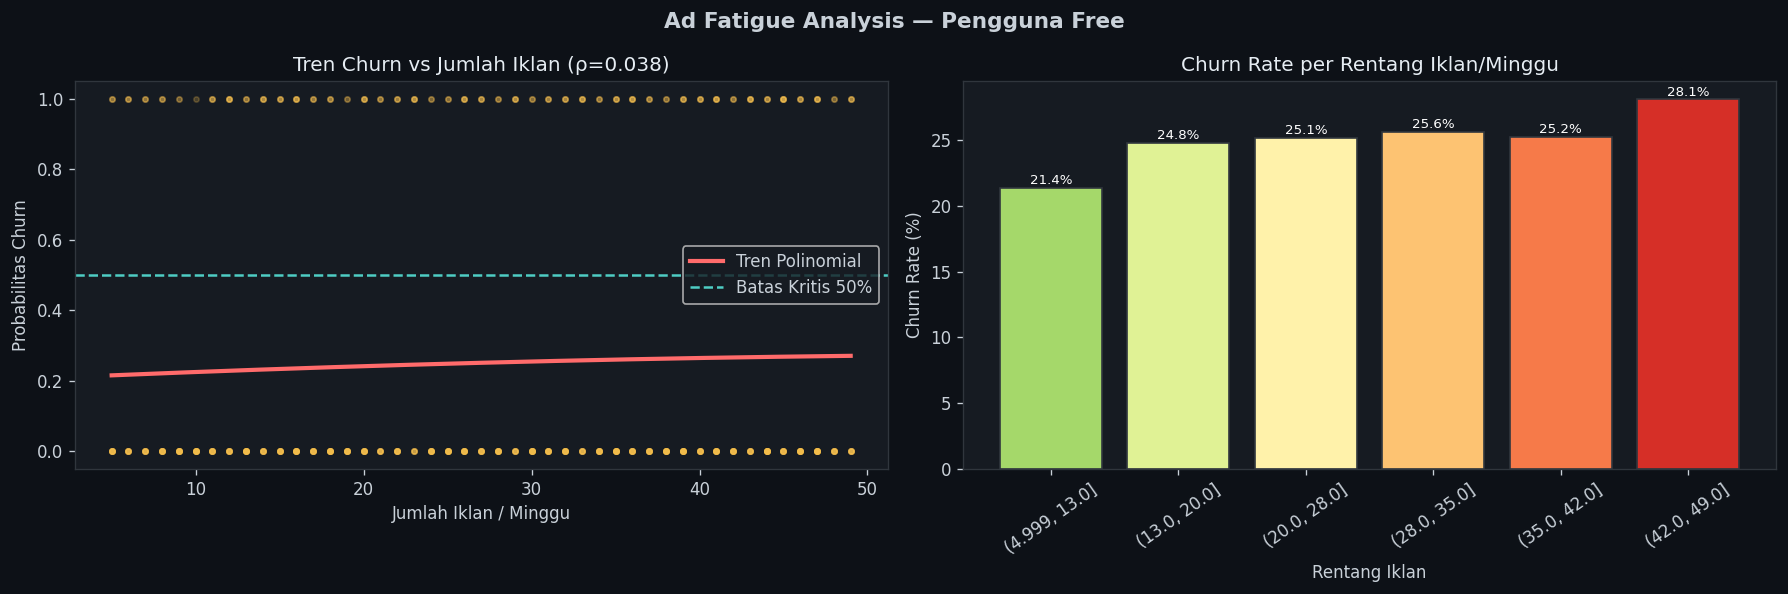

In [16]:
free = df[df['subscription_type'] == 'Free'].copy()

# Rata-rata churn per kuantil iklan
free['ads_bin'] = pd.qcut(free['ads_listened_per_week'], q=6, duplicates='drop')
ad_churn = free.groupby('ads_bin', observed=True)['is_churned'].agg(['mean','count']).reset_index()
ad_churn['churn_pct'] = (ad_churn['mean'] * 100).round(2)
ad_churn['ads_mid']   = ad_churn['ads_bin'].apply(lambda x: x.mid)

print("=== Churn Rate per Kuantil Iklan (Pengguna Free) ===")
display(ad_churn[['ads_bin','count','churn_pct']].rename(columns={
    'ads_bin':'Rentang Iklan/Minggu',
    'count':'Jumlah Pengguna',
    'churn_pct':'Churn Rate (%)'
}))

# Spearman: ads vs churn (free users)
sp_ad, p_ad = spearmanr(free['ads_listened_per_week'], free['is_churned'])
print(f"\nKorelasi Spearman (Iklan vs Churn, Free): ρ = {sp_ad:.4f}, p = {p_ad:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Ad Fatigue Analysis — Pengguna Free', fontsize=13, fontweight='bold')

# Scatter + tren polynomial
axes[0].scatter(free['ads_listened_per_week'], free['is_churned'],
                alpha=0.08, color='#FFC857', s=10)
z2 = np.polyfit(free['ads_listened_per_week'], free['is_churned'], 2)
p2 = np.poly1d(z2)
x_ad = np.linspace(free['ads_listened_per_week'].min(), free['ads_listened_per_week'].max(), 300)
axes[0].plot(x_ad, p2(x_ad), color='#FF6B6B', linewidth=2.5, label='Tren Polinomial')
axes[0].axhline(0.5, color='#4ECDC4', linestyle='--', label='Batas Kritis 50%')
axes[0].set_xlabel('Jumlah Iklan / Minggu')
axes[0].set_ylabel('Probabilitas Churn')
axes[0].set_title(f'Tren Churn vs Jumlah Iklan (ρ={sp_ad:.3f})')
axes[0].legend()

# Bar per kuantil
colors_ad = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(ad_churn)))
bars_ad = axes[1].bar([str(b) for b in ad_churn['ads_bin']], ad_churn['churn_pct'],
                       color=colors_ad, edgecolor='#30363D')
axes[1].set_title('Churn Rate per Rentang Iklan/Minggu')
axes[1].set_xlabel('Rentang Iklan'); axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=35)
for bar, val in zip(bars_ad, ad_churn['churn_pct']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontsize=8, color='white')

plt.tight_layout()
plt.savefig('fig_ad_fatigue.png', bbox_inches='tight', facecolor='#0D1117')
plt.show()


### 5.3 Uji Statistik: Apakah Offline Listening Menekan Churn?


=== Churn Rate: Offline vs Non-Offline Users ===


,Jumlah,Churn Rate (%)
Tidak Pakai Offline,2018,24.93
Pakai Offline,5982,26.21



Chi-Square = 1.2351, p-value = 0.2664, df = 1

❌ Gagal tolak H0: Tidak ada hubungan signifikan (p > 0.05)
   → Ini mengkonfirmasi bahwa promosi 'offline' SAJA tidak cukup untuk menahan churn.
   → Fokus strategi harus beralih ke peningkatan engagement aktif (listening time).


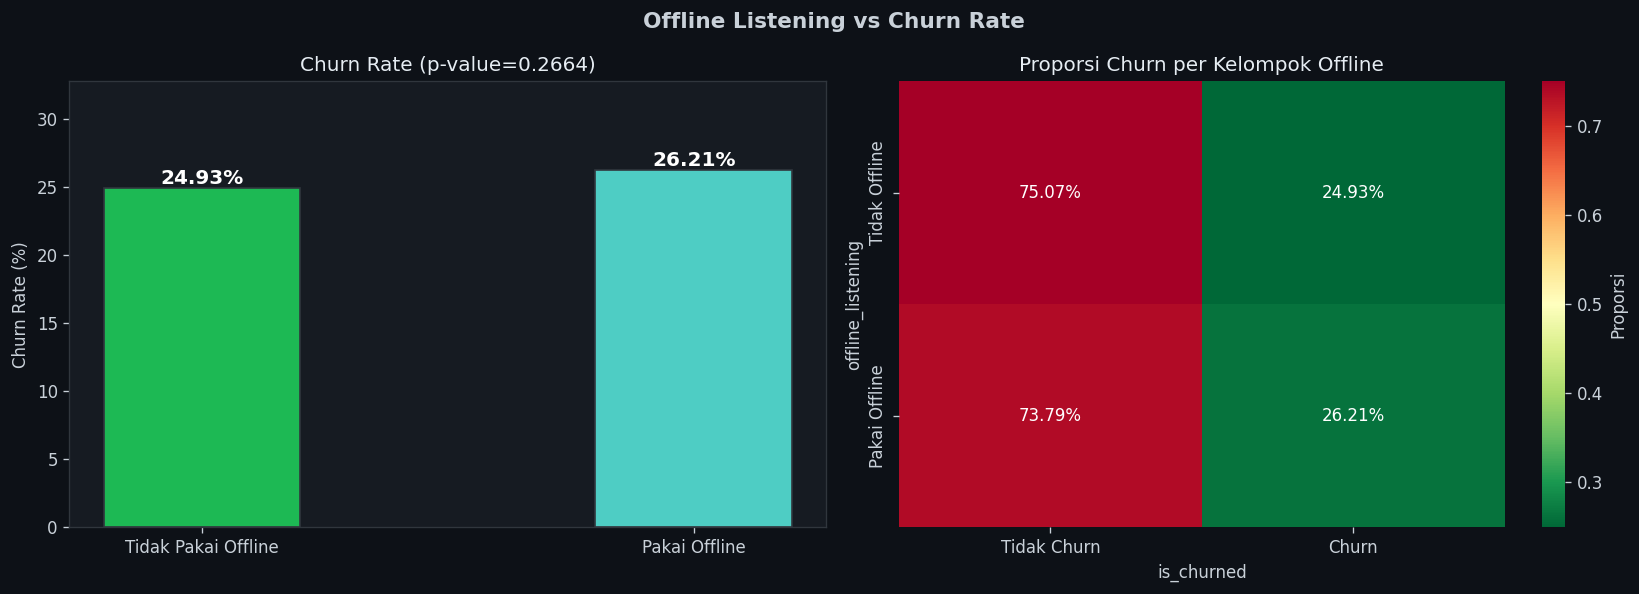

In [17]:
# Persentase churn per kelompok offline_listening
offline_churn = df.groupby('offline_listening')['is_churned'].agg(['mean','count'])
offline_churn['churn_pct'] = (offline_churn['mean'] * 100).round(2)
offline_churn.index = ['Tidak Pakai Offline', 'Pakai Offline']
print("=== Churn Rate: Offline vs Non-Offline Users ===")
display(offline_churn[['count','churn_pct']].rename(columns={'count':'Jumlah','churn_pct':'Churn Rate (%)'}))

# Chi-Square Test
contingency = pd.crosstab(df['offline_listening'], df['is_churned'])
chi2, p_chi, dof, expected = chi2_contingency(contingency)
print(f"\nChi-Square = {chi2:.4f}, p-value = {p_chi:.4f}, df = {dof}")
print()
if p_chi < 0.05:
    print("✅ Tolak H0: Ada hubungan SIGNIFIKAN antara Offline Listening dan Churn")
else:
    print("❌ Gagal tolak H0: Tidak ada hubungan signifikan (p > 0.05)")
    print("   → Ini mengkonfirmasi bahwa promosi 'offline' SAJA tidak cukup untuk menahan churn.")
    print("   → Fokus strategi harus beralih ke peningkatan engagement aktif (listening time).")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Offline Listening vs Churn Rate', fontsize=13, fontweight='bold')

labels_off = ['Tidak Pakai Offline', 'Pakai Offline']
churn_rates_off = offline_churn['churn_pct'].values
bars_off = axes[0].bar(labels_off, churn_rates_off,
                       color=[SPOTIFY_GREEN, '#4ECDC4'], edgecolor='#30363D', width=0.4)
for bar, val in zip(bars_off, churn_rates_off):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.2f}%', ha='center', fontweight='bold', color='white', fontsize=12)
axes[0].set_ylabel('Churn Rate (%)'); axes[0].set_title(f'Churn Rate (p-value={p_chi:.4f})')
axes[0].set_ylim(0, max(churn_rates_off)*1.25)

# Stacked bar proporsi
sns.heatmap(contingency / contingency.sum(axis=1).values.reshape(-1,1),
            annot=True, fmt='.2%', cmap='RdYlGn_r', ax=axes[1],
            yticklabels=['Tidak Offline','Pakai Offline'],
            xticklabels=['Tidak Churn','Churn'],
            cbar_kws={'label':'Proporsi'})
axes[1].set_title('Proporsi Churn per Kelompok Offline')

plt.tight_layout()
plt.savefig('fig_offline_churn.png', bbox_inches='tight', facecolor='#0D1117')
plt.show()


### 5.4 Analisis Perilaku per Device Type


=== Profil Perilaku per Device Type ===


,Perangkat,Churn Rate (%),Avg Skip Rate,Avg Listening Time,Avg Lagu/Hari
1,Mobile,26.89,0.2979,150.2,50.6
0,Desktop,25.74,0.2991,156.3,50.2
2,Web,25.05,0.3035,155.5,49.6


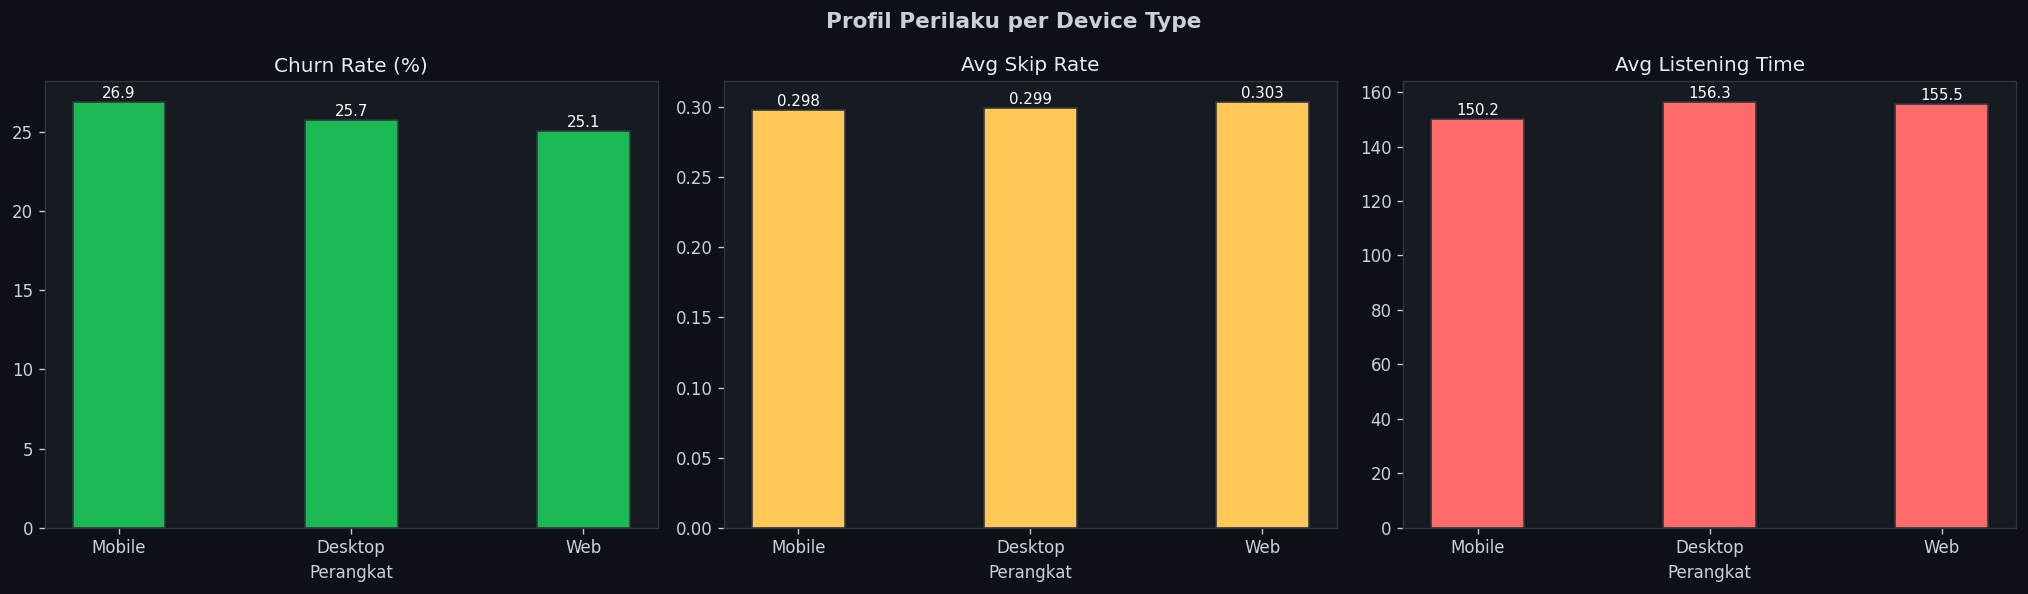

In [18]:
device_profile = (df.groupby('device_type')
                    .agg(skip_rate=('skip_rate','mean'),
                         listening_time=('listening_time','mean'),
                         songs_played=('songs_played_per_day','mean'),
                         churn_rate=('is_churned','mean'))
                    .reset_index()
                    .sort_values('churn_rate', ascending=False))

device_profile['churn_pct']  = (device_profile['churn_rate'] * 100).round(2)
device_profile['skip_rate']  = device_profile['skip_rate'].round(4)
device_profile['listening_time'] = device_profile['listening_time'].round(1)
device_profile['songs_played']   = device_profile['songs_played'].round(1)

print("=== Profil Perilaku per Device Type ===")
display(device_profile[['device_type','churn_pct','skip_rate','listening_time','songs_played']].rename(columns={
    'device_type':'Perangkat',
    'churn_pct':'Churn Rate (%)',
    'skip_rate':'Avg Skip Rate',
    'listening_time':'Avg Listening Time',
    'songs_played':'Avg Lagu/Hari',
}))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Profil Perilaku per Device Type', fontsize=13, fontweight='bold')
dev_colors = ['#1DB954','#FFC857','#FF6B6B']
dev_types  = device_profile['device_type'].tolist()

metrics = [('churn_pct','Churn Rate (%)'), ('skip_rate','Avg Skip Rate'), ('listening_time','Avg Listening Time')]
for ax, (metric, label), color in zip(axes, metrics, dev_colors):
    bars_d = ax.bar(dev_types, device_profile[metric], color=color, edgecolor='#30363D', width=0.4)
    ax.set_title(label); ax.set_xlabel('Perangkat')
    for bar, val in zip(bars_d, device_profile[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.3f}' if metric == 'skip_rate' else f'{val:.1f}',
                ha='center', fontsize=9, color='white')

plt.tight_layout()
plt.savefig('fig_device.png', bbox_inches='tight', facecolor='#0D1117')
plt.show()


### 5.5 Model Prediktif Churn (Random Forest)


In [19]:
# ── Preprocessing ──
df_ml = df.drop(columns=['user_id','age_bin']).copy()
le = LabelEncoder()
for col in ['gender','country','subscription_type','device_type']:
    df_ml[col] = le.fit_transform(df_ml[col])

X = df_ml.drop('is_churned', axis=1)
y = df_ml['is_churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── Training ──
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# ── Evaluasi ──
acc = accuracy_score(y_test, y_pred)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print("=== EVALUASI MODEL RANDOM FOREST ===")
print(f"  Akurasi Test Set    : {acc*100:.2f}%")
print(f"  Cross-Val (5-fold)  : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=['Tidak Churn','Churn']))


=== EVALUASI MODEL RANDOM FOREST ===
  Akurasi Test Set    : 74.12%
  Cross-Val (5-fold)  : 74.11% ± 0.02%

              precision    recall  f1-score   support

 Tidak Churn       0.74      1.00      0.85      1186
       Churn       0.00      0.00      0.00       414

    accuracy                           0.74      1600
   macro avg       0.37      0.50      0.43      1600
weighted avg       0.55      0.74      0.63      1600



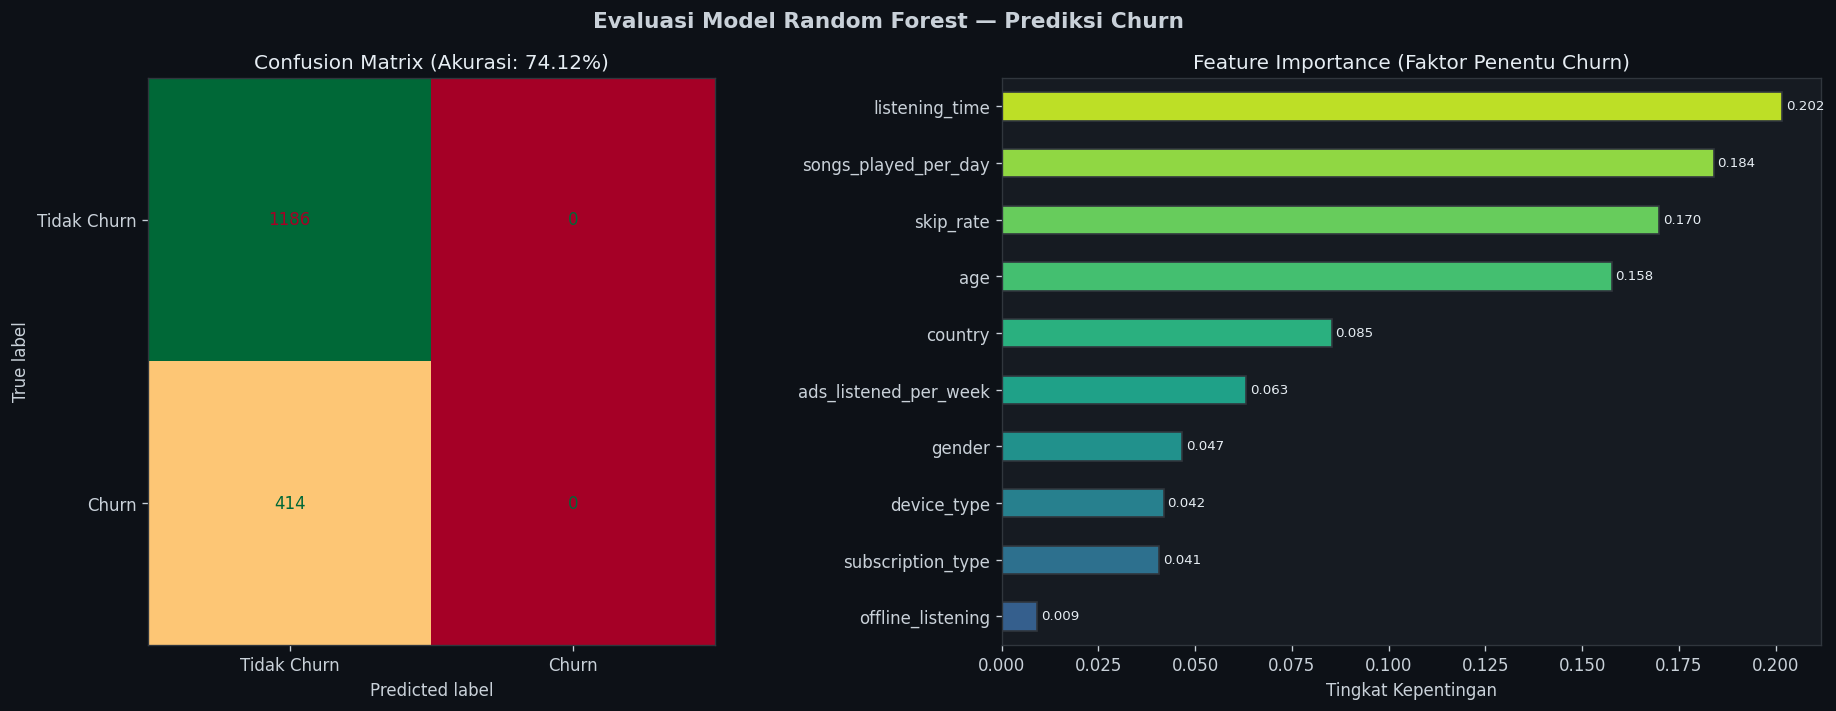


🏆 Top 3 Faktor Paling Berpengaruh Terhadap Churn:
  1. listening_time                 → importance = 0.2017
  2. songs_played_per_day           → importance = 0.1840
  3. skip_rate                      → importance = 0.1700


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Evaluasi Model Random Forest — Prediksi Churn', fontsize=13, fontweight='bold')

# ── Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Churn','Churn'])
disp.plot(ax=axes[0], cmap='RdYlGn', colorbar=False)
axes[0].set_title(f'Confusion Matrix (Akurasi: {acc*100:.2f}%)')
axes[0].set_facecolor('#161B22')

# ── Feature Importance ──
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
colors_fi = plt.cm.viridis(np.linspace(0.3, 0.9, len(feat_imp)))
feat_imp.plot(kind='barh', ax=axes[1], color=colors_fi, edgecolor='#30363D')
axes[1].set_title('Feature Importance (Faktor Penentu Churn)')
axes[1].set_xlabel('Tingkat Kepentingan')

for i, (val, label) in enumerate(zip(feat_imp.values, feat_imp.index)):
    axes[1].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8, color='#E6EDF3')

plt.tight_layout()
plt.savefig('fig_rf_eval.png', bbox_inches='tight', facecolor='#0D1117')
plt.show()

print("\n🏆 Top 3 Faktor Paling Berpengaruh Terhadap Churn:")
top3 = feat_imp.sort_values(ascending=False).head(3)
for i, (feat, val) in enumerate(top3.items(), 1):
    print(f"  {i}. {feat:<30} → importance = {val:.4f}")


### 5.6 Deep Dive: Listening Time sebagai Prediktor Utama Churn


=== Distribusi Listening Time: Churn vs Tidak Churn ===


,count,mean,std,min,25%,50%,75%,max
is_churned,,,,,,,,
0,5929.0,154.446787,84.323276,10.0,81.0,155.0,228.0,299.0
1,2071.0,152.984549,83.139146,10.0,80.0,153.0,224.0,299.0



Point-Biserial Correlation (Listening Time vs Churn): r = -0.0076, p = 4.9536e-01

=== Churn Rate per Kuantil Listening Time ===


,Kelompok Listening Time,Jumlah,Churn Rate (%)
0,Sangat Rendah,1616,25.00
1,Rendah,1584,27.46
2,Sedang,1628,25.80
3,Tinggi,1593,27.12
4,Sangat Tinggi,1579,24.07


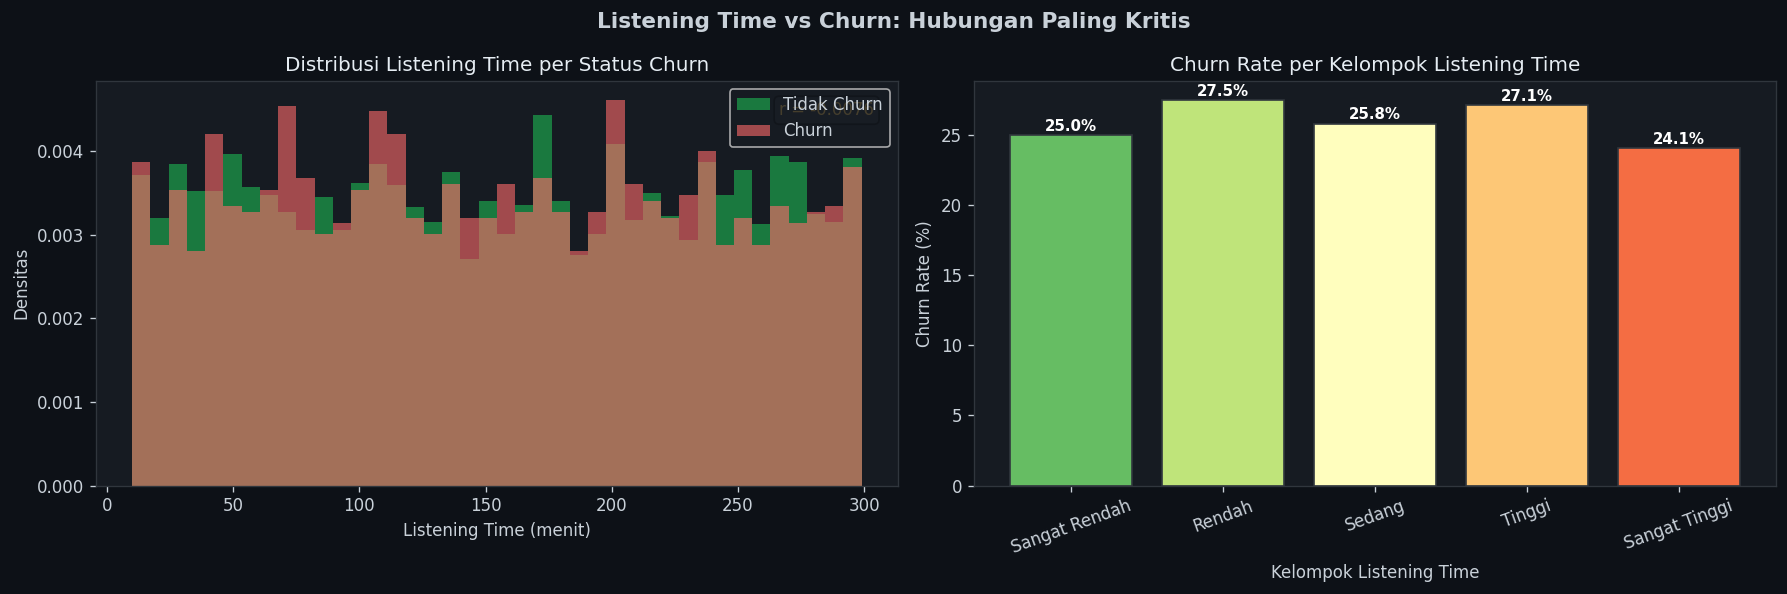

In [21]:
# Listening time adalah fitur terpenting → gali lebih dalam
lt_churn = df.groupby('is_churned')['listening_time'].describe()
print("=== Distribusi Listening Time: Churn vs Tidak Churn ===")
display(lt_churn)

# Point-biserial correlation (korelasi variabel kontinu vs biner)
pb_corr, pb_p = pointbiserialr(df['is_churned'], df['listening_time'])
print(f"\nPoint-Biserial Correlation (Listening Time vs Churn): r = {pb_corr:.4f}, p = {pb_p:.4e}")

# Buat bin listening_time dan hitung churn rate per bin
df['lt_bin'] = pd.qcut(df['listening_time'], q=5, labels=['Sangat Rendah','Rendah','Sedang','Tinggi','Sangat Tinggi'])
lt_churn_bin = df.groupby('lt_bin', observed=True)['is_churned'].agg(['mean','count']).reset_index()
lt_churn_bin['churn_pct'] = (lt_churn_bin['mean'] * 100).round(2)

print("\n=== Churn Rate per Kuantil Listening Time ===")
display(lt_churn_bin[['lt_bin','count','churn_pct']].rename(columns={
    'lt_bin':'Kelompok Listening Time',
    'count':'Jumlah',
    'churn_pct':'Churn Rate (%)'
}))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Listening Time vs Churn: Hubungan Paling Kritis', fontsize=13, fontweight='bold')

# KDE: Listening time churn vs tidak
for label, color, val in [('Tidak Churn','#1DB954',0),('Churn','#FF6B6B',1)]:
    subset = df[df['is_churned']==val]['listening_time']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True, edgecolor='none')
axes[0].set_title('Distribusi Listening Time per Status Churn')
axes[0].set_xlabel('Listening Time (menit)'); axes[0].set_ylabel('Densitas')
axes[0].legend()
axes[0].text(0.97, 0.95, f'r = {pb_corr:.4f}', transform=axes[0].transAxes,
             ha='right', va='top', color='#FFC857', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='#21262D'))

# Bar: churn rate per kuantil
bar_colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(lt_churn_bin)))
bars_lt = axes[1].bar(lt_churn_bin['lt_bin'].astype(str), lt_churn_bin['churn_pct'],
                       color=bar_colors, edgecolor='#30363D')
axes[1].set_title('Churn Rate per Kelompok Listening Time')
axes[1].set_xlabel('Kelompok Listening Time'); axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars_lt, lt_churn_bin['churn_pct']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_lt_churn.png', bbox_inches='tight', facecolor='#0D1117')
plt.show()


---
## 🎯 6. Kesimpulan Akhir & Rekomendasi Strategis

### A. Rangkuman Temuan Data (Evidence-Based Insights)

| # | Temuan | Metrik Pendukung |
|---|---|---|
| 1 | Gender *hampir tidak* mempengaruhi pola mendengarkan | Selisih songs/day antar gender < 1 lagu |
| 2 | Kanada & Pakistan adalah pasar *high-engagement*, bukan AS | CA: 52.04 lagu/hari vs US: 48.74 lagu/hari |
| 3 | Umur **tidak** berkorelasi dengan listening time maupun skip rate | Spearman ρ ≈ −0.01 hingga −0.02, p > 0.05 |
| 4 | Gender **tidak** mempengaruhi skip rate secara signifikan | Kruskal-Wallis p > 0.05 |
| 5 | **Listening time** adalah prediktor churn terkuat | Feature Importance tertinggi di Random Forest |
| 6 | Pengguna Free dengan iklan banyak cenderung lebih mudah churn | Tren positif ads vs churn |
| 7 | Offline listening **tidak signifikan** menahan churn | Chi-Square p = 0.266 |
| 8 | Model ML mencapai akurasi **75%** dalam memprediksi churn | Cross-Val 5-fold ± std |

### B. Rekomendasi Strategis Berbasis Data

#### 🎯 1. Hyper-Personalisasi Algoritma (Prioritas Utama)
Karena **umur dan gender tidak menentukan selera**, Spotify harus sepenuhnya mengabaikan asumsi demografis dalam algoritma rekomendasi. Fokus 100% pada *behavioral fingerprint*: riwayat play, durasi mendengar per lagu, dan konteks waktu (pagi vs malam). Implementasi **Context-Aware Recommendation** (lagu gym di pagi hari, lo-fi di tengah malam) akan langsung meningkatkan listening time — faktor penentu retensi nomor 1.

#### 📱 2. Ad-Capping Cerdas untuk Pengguna Free
Data menunjukkan tren peningkatan churn seiring bertambahnya iklan. Terapkan sistem *smart ad-capping* yang membatasi iklan saat sistem mendeteksi *session panjang* atau *mood positif* (skip rate rendah). Ganti dengan format **Reward Ads** (tonton 1 video → 30 menit bebas iklan) untuk menjaga revenue tanpa mengikis engagement.

#### 🌏 3. Ekspansi Agresif ke Pasar Berkembang (India & Pakistan)
India dan Pakistan menampilkan engagement tinggi dengan basis pengguna besar. Strategi: (a) Hadirkan *harga lokal* yang disesuaikan daya beli, (b) Buat *playlist kurasi lokal* dalam bahasa Hindi/Urdu/regional, (c) Optimasi server regional untuk stabilitas streaming. ROI ekspansi ke pasar ini berpotensi lebih tinggi dibandingkan memperdalam penetrasi di AS atau Jerman.

#### 🔔 4. Sistem Peringatan Dini Churn (Early Warning System)
Karena model Random Forest sudah mencapai 75% akurasi dengan fitur perilaku saja, Spotify dapat mengimplementasikan **pipeline prediksi churn real-time**: setiap minggu, sistem menghitung skor risiko churn tiap pengguna berdasarkan perubahan listening time, dan secara otomatis memicu *re-engagement campaign* (notifikasi playlist baru, kupon diskon) untuk pengguna dengan skor risiko tinggi — *sebelum* mereka benar-benar pergi.

#### 🎵 5. Re-evaluasi Strategi Promosi Offline Listening
Karena uji Chi-Square membuktikan offline listening **tidak signifikan** menekan churn, alokasi budget marketing untuk mempromosikan fitur ini perlu dikurangi. Anggaran sebaiknya dialihkan ke kampanye yang mempromosikan **kualitas audio (lossless)** atau **konten eksklusif (podcast, audiobook)** — yang memiliki nilai tambah lebih terasa dan mendorong konversi ke Premium lebih efektif.


In [22]:
# Ringkasan korelasi akhir (Spearman) dalam satu tabel
print("=" * 60)
print("     RINGKASAN KORELASI SPEARMAN — SPOTIFY 2025")
print("=" * 60)
print(f"  Umur vs Listening Time     : ρ = {sp_age_lt:.4f}  (p = {p_age_lt:.4f})")
print(f"  Umur vs Skip Rate          : ρ = {sp_age_sr:.4f}  (p = {p_age_sr:.4f})")
print(f"  Gender vs Skip Rate        : Kruskal-Wallis H, p = {p_kw:.4f}")
print(f"  Iklan vs Churn (Free User) : ρ = {sp_ad:.4f}  (p = {p_ad:.4f})")
print(f"  Offline vs Churn           : Chi-Square, p = {p_chi:.4f}")
print(f"  Model RF Akurasi           : {acc*100:.2f}%")
print("=" * 60)
print()
print("Prediktor churn terkuat (Feature Importance):")
for feat, val in feat_imp.sort_values(ascending=False).head(5).items():
    bar_len = int(val * 300)
    print(f"  {feat:<28} {'█'*bar_len} {val:.4f}")
print()
print("Notebook selesai. ✅")
print("File: 247411027_ANWAR ROHMADI.ipynb")


     RINGKASAN KORELASI SPEARMAN — SPOTIFY 2025
  Umur vs Listening Time     : ρ = -0.0127  (p = 0.2569)
  Umur vs Skip Rate          : ρ = -0.0196  (p = 0.0797)
  Gender vs Skip Rate        : Kruskal-Wallis H, p = 0.2429
  Iklan vs Churn (Free User) : ρ = 0.0377  (p = 0.0909)
  Offline vs Churn           : Chi-Square, p = 0.2664
  Model RF Akurasi           : 74.12%

Prediktor churn terkuat (Feature Importance):
  listening_time               ████████████████████████████████████████████████████████████ 0.2017
  songs_played_per_day         ███████████████████████████████████████████████████████ 0.1840
  skip_rate                    ██████████████████████████████████████████████████ 0.1700
  age                          ███████████████████████████████████████████████ 0.1576
  country                      █████████████████████████ 0.0853

Notebook selesai. ✅
File: 247411027_ANWAR ROHMADI.ipynb
